In [73]:
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [41]:
# theoric ribosome size coverage and distance between 2 ribosomes
rib_size = 10 # aa
dist_two_rib = 30 #aa

elongation_rates = np.arange(1,50) # aa/sec

min_initiation_rates = rib_size/elongation_rates

initiation_rates = (dist_two_rib+rib_size)/elongation_rates

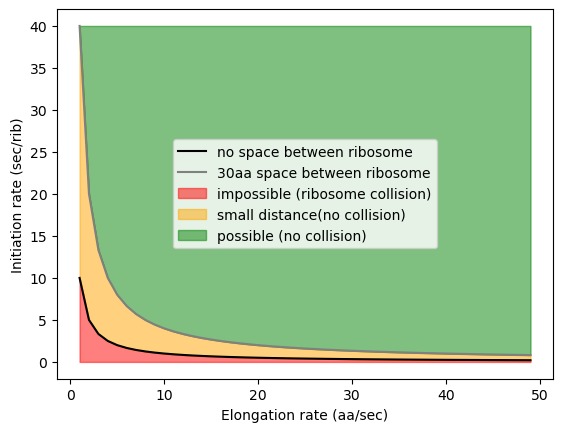

In [45]:
fig, ax = plt.subplots()
ax.plot(elongation_rates, min_initiation_rates, color="black", label="no space between ribosome")
ax.plot(elongation_rates, initiation_rates, color="grey", label=str(dist_two_rib)+"aa space between ribosome")

ax.fill_between(elongation_rates, min_initiation_rates, color="red", alpha=0.5, label="impossible (ribosome collision)")
ax.fill_between(elongation_rates, min_initiation_rates, initiation_rates,  color="orange", alpha=0.5, label="small distance(no collision)")
ax.fill_between(elongation_rates, initiation_rates, (dist_two_rib+rib_size), color="green", alpha=0.5, label="possible (no collision)")

ax.set_xlabel("Elongation rate (aa/sec)")
ax.set_ylabel("Initiation rate (sec/rib)")
ax.legend()


# Known value: ribosome density only

In [56]:
## Variable known
# ribosome density
rib_density = 30 # aa/rib

elongation_rates = np.arange(1,50) # aa/sec

min_initiation_rates = rib_density/elongation_rates


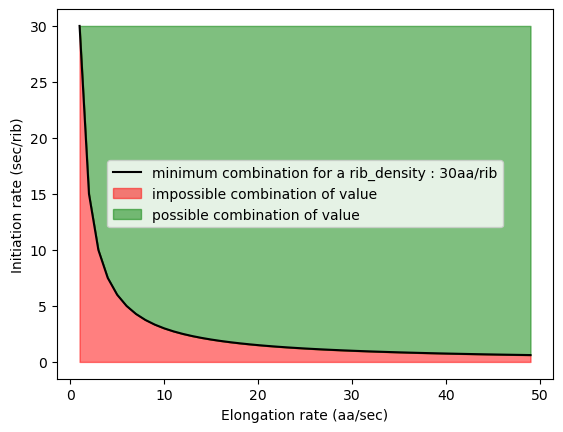

In [57]:
fig, ax = plt.subplots()
ax.plot(elongation_rates, min_initiation_rates, color="black", label="minimum combination for a rib_density : "+str(rib_density)+"aa/rib")

ax.fill_between(elongation_rates, min_initiation_rates, color="red", alpha=0.5, label="impossible combination of value")

ax.fill_between(elongation_rates, min_initiation_rates, rib_density, color="green", alpha=0.5, label="possible combination of value")

ax.set_xlabel("Elongation rate (aa/sec)")
ax.set_ylabel("Initiation rate (sec/rib)")
ax.legend()


In [59]:
## Variable known
# ribosome density
rib_density = np.arange(10,100,5) # aa/rib

elongation_rates = np.arange(1,50) # aa/sec
min_initiation_rates_all = []

for rb in rib_density:

    min_initiation_rates = rb/elongation_rates
    min_initiation_rates_all.append(min_initiation_rates)


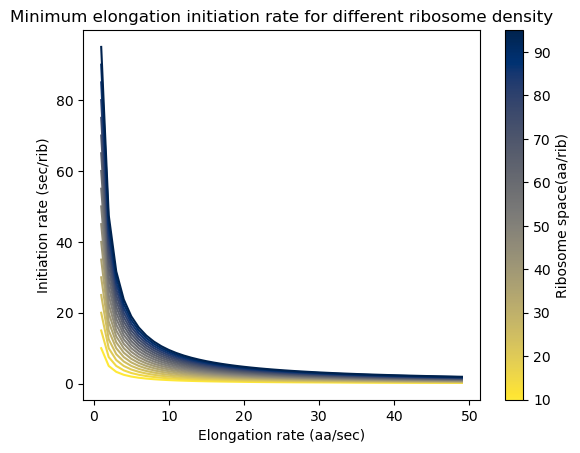

In [95]:
normalize = mcolors.Normalize(vmin=rib_density.min(), vmax=rib_density.max())
colormap = cm.cividis_r


fig, ax = plt.subplots()

i=0
for rb in rib_density:
    ax.plot(elongation_rates, min_initiation_rates_all[i], 
            color=colormap(normalize(rb)),
            )
    i+=1

# setup the colorbar
scalarmappaple = cm.ScalarMappable(norm=normalize, cmap=colormap)
scalarmappaple.set_array(rib_density)
cbar = fig.colorbar(scalarmappaple, ax=ax)
cbar.set_label('Ribosome space(aa/rib)', rotation=90)

ax.set_xlabel("Elongation rate (aa/sec)")
ax.set_ylabel("Initiation rate (sec/rib)")

_=ax.set_title("Minimum elongation initiation rate for different ribosome density")